In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  # Create 2 virtual GPUs with 1GB memory each
  try:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=1024),
         tf.config.LogicalDeviceConfiguration(memory_limit=1024)])
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPU,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Virtual devices must be set before GPUs have been initialized
    print(e)

1 Physical GPU, 2 Logical GPUs


In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
from keras.models import Sequential, load_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
from keras.utils import np_utils

In [4]:
df = pd.read_csv('archive/02-16-2018.csv')
df.drop(df.loc[df['Label'] == 'Label'].index, inplace=True)

In [5]:
metadata = ['fl_dur' #Flow duration
,'tot_fw_pk' #Total packets in the forward direction
,'tot_bw_pk' #Total packets in the backward direction
,'tot_l_fw_pkt' #Total size of packet in forward direction
,'fw_pkt_l_max' #Maximum size of packet in forward direction
,'fw_pkt_l_min' #Minimum size of packet in forward direction
,'fw_pkt_l_avg' #Average size of packet in forward direction
,'fw_pkt_l_std' #Standard deviation size of packet in forward direction
,'Bw_pkt_l_max' #Maximum size of packet in backward direction
,'Bw_pkt_l_min' #Minimum size of packet in backward direction
,'Bw_pkt_l_avg' #Mean size of packet in backward direction
,'Bw_pkt_l_std' #Standard deviation size of packet in backward direction
,'fl_byt_s' #flow byte rate that is number of packets transferred per second
,'fl_pkt_s' #flow packets rate that is number of packets transferred per second
,'fl_iat_avg' #Average time between two flows
,'fl_iat_std' #Standard deviation time two flows
,'fl_iat_max' #Maximum time between two flows
,'fl_iat_min' #Minimum time between two flows
,'fw_iat_tot' #Total time between two packets sent in the forward direction
,'fw_iat_avg' #Mean time between two packets sent in the forward direction
,'fw_iat_std' #Standard deviation time between two packets sent in the forward direction
,'fw_iat_max' #Maximum time between two packets sent in the forward direction
,'fw_iat_min' #Minimum time between two packets sent in the forward direction
,'bw_iat_tot' #Total time between two packets sent in the backward direction
,'bw_iat_avg' #Mean time between two packets sent in the backward direction
,'bw_iat_std' #Standard deviation time between two packets sent in the backward direction
,'bw_iat_max' #Maximum time between two packets sent in the backward direction
,'bw_iat_min' #Minimum time between two packets sent in the backward direction
,'fw_psh_flag' #Number of times the PSH flag was set in packets travelling in the forward direction (0 for UDP)
,'bw_psh_flag' #Number of times the PSH flag was set in packets travelling in the backward direction (0 for UDP)
,'fw_urg_flag' #Number of times the URG flag was set in packets travelling in the forward direction (0 for UDP)
,'bw_urg_flag' #Number of times the URG flag was set in packets travelling in the backward direction (0 for UDP)
,'fw_hdr_len' #Total bytes used for headers in the forward direction
,'bw_hdr_len' #Total bytes used for headers in the forward direction
,'fw_pkt_s' #Number of forward packets per second
,'bw_pkt_s' #Number of backward packets per second
,'pkt_len_min' #Minimum length of a flow
,'pkt_len_max' #Maximum length of a flow
,'pkt_len_avg' #Mean length of a flow
,'pkt_len_std' #Standard deviation length of a flow
,'pkt_len_va' #Minimum inter-arrival time of packet
,'fin_cnt' #Number of packets with FIN
,'syn_cnt' #Number of packets with SYN
,'rst_cnt' #Number of packets with RST
,'pst_cnt' #Number of packets with PUSH
,'ack_cnt' #Number of packets with ACK
,'urg_cnt' #Number of packets with URG
,'cwe_cnt' #Number of packets with CWE
,'ece_cnt' #Number of packets with ECE
,'down_up_ratio' #Download and upload ratio
,'pkt_size_avg' #Average size of packet
,'fw_seg_avg' #Average size observed in the forward direction
,'bw_seg_avg' #Average size observed in the backward direction
,'fw_byt_blk_avg' #Average number of bytes bulk rate in the forward direction
,'fw_pkt_blk_avg' #Average number of packets bulk rate in the forward direction
,'fw_blk_rate_avg' #Average number of bulk rate in the forward direction
,'bw_byt_blk_avg' #Average number of bytes bulk rate in the backward direction
,'bw_pkt_blk_avg' #Average number of packets bulk rate in the backward direction
,'bw_blk_rate_avg' #Average number of bulk rate in the backward direction
,'subfl_fw_pk' #The average number of packets in a sub flow in the forward direction
,'subfl_fw_byt' #The average number of bytes in a sub flow in the forward direction
,'subfl_bw_pkt' #The average number of packets in a sub flow in the backward direction
,'subfl_bw_byt' #The average number of bytes in a sub flow in the backward direction
,'fw_win_byt' #Number of bytes sent in initial window in the forward direction
,'bw_win_byt' ## of bytes sent in initial window in the backward direction
,'Fw_act_pkt' ## of packets with at least 1 byte of TCP data payload in the forward direction
,'fw_seg_min' #Minimum segment size observed in the forward direction
,'atv_avg' #Mean time a flow was active before becoming idle
,'atv_std' #Standard deviation time a flow was active before becoming idle
,'atv_max' #Maximum time a flow was active before becoming idle
,'atv_min' #Minimum time a flow was active before becoming idle
,'idl_avg' #Mean time a flow was idle before becoming active
,'idl_std' #Standard deviation time a flow was idle before becoming active
,'idl_max' #Maximum time a flow was idle before becoming active
,'idl_min' #Minimum time a flow was idle before becoming active
]

In [6]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [7]:
features = ['Fwd Pkt Len Std', 'Fwd Pkt Len Mean',
       'Fwd Pkt Len Max', 'Fwd Seg Size Avg', 'Pkt Len Std', 'Flow IAT Std',
       'Bwd Pkt Len Std', 'Bwd Seg Size Avg', 'Pkt Size Avg',
       'Subflow Fwd Byts']

In [8]:
def targetify(s):
    if s == 'Benign':
        return 0
    else:
        return 1

In [9]:
X = df[features]
X[features] = X[features].apply(pd.to_numeric, errors='coerce', axis=1)
X = X.fillna(0)
labels = df['Label']    #For multiclass classification


In [10]:
df['Target']=df['Label'].apply(targetify)
y = df['Target']

In [11]:
df = df[['Fwd Pkt Len Std', 'Fwd Pkt Len Mean',
       'Fwd Pkt Len Max', 'Fwd Seg Size Avg', 'Pkt Len Std', 'Flow IAT Std',
       'Bwd Pkt Len Std', 'Bwd Seg Size Avg', 'Pkt Size Avg',
       'Subflow Fwd Byts','Target']]
df.to_csv('processed.csv')

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print (X_train.shape, y_train.shape)
print( X_test.shape, y_test.shape)

(838859, 10) (838859,)
(209715, 10) (209715,)


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [14]:
ML_Model1 = []
accuracy1 = []
precision1 = []
recall1 = []
f1score1 = []

#function to call for storing the results
def storeResults1(model, a,b,c,d):
    ML_Model1.append(model)
    accuracy1.append(round(a, 3))
    precision1.append(round(b, 3))
    recall1.append(round(c, 3))
    f1score1.append(round(d, 3))

# DNN

In [15]:
from keras.layers import Activation, Dense, Dropout, BatchNormalization, Input
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [16]:
def nn():
    inputs = Input(name='inputs', shape=[X_train.shape[1],])
    layer = Dense(128, name='FC1')(inputs)
    layer = BatchNormalization(name='BC1')(layer)
    layer = Activation('relu', name='Activation1')(layer)
    layer = Dropout(0.3, name='Dropout1')(layer)
    layer = Dense(128, name='FC2')(layer)
    layer = BatchNormalization(name='BC2')(layer)
    layer = Activation('relu', name='Activation2')(layer)
    layer = Dropout(0.3, name='Dropout2')(layer)
    layer = Dense(128, name='FC3')(layer)
    layer = BatchNormalization(name='BC3')(layer)
    layer = Dropout(0.3, name='Dropout3')(layer)
    layer = Dense(1, name='OutLayer')(layer)
    layer = Activation('sigmoid', name='sigmoid')(layer)
    model = Model(inputs=inputs, outputs=layer)
    return model

In [17]:
model = nn()
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inputs (InputLayer)          [(None, 10)]              0         
_________________________________________________________________
FC1 (Dense)                  (None, 128)               1408      
_________________________________________________________________
BC1 (BatchNormalization)     (None, 128)               512       
_________________________________________________________________
Activation1 (Activation)     (None, 128)               0         
_________________________________________________________________
Dropout1 (Dropout)           (None, 128)               0         
_________________________________________________________________
FC2 (Dense)                  (None, 128)               16512     
_________________________________________________________________
BC2 (BatchNormalization)     (None, 128)               512   

In [18]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau()
early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

In [19]:
history = model.fit(x=X_train, y=y_train, epochs=10, validation_data=(X_train, y_train), callbacks=[reduce_lr, early_stopping], verbose=0,steps_per_epoch=500,validation_steps=500)

In [20]:
import math
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt

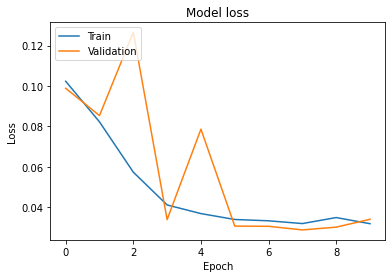

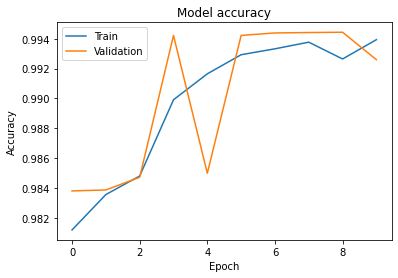

In [21]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss.png', format='png', dpi=1200)
plt.show()


# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('accuracy.png', format='png', dpi=1200)
plt.show()

In [22]:
y_pred = model.predict(X_test)
y_pred = np.around(y_pred)

nn_acc = accuracy_score(y_pred, y_test)
nn_prec = precision_score(y_pred, y_test,average='weighted')
nn_rec = recall_score(y_pred, y_test,average='weighted')
nn_f1 = f1_score(y_pred, y_test,average='weighted')

In [44]:
storeResults1('Deep Neural Network',nn_acc,nn_prec,nn_rec,nn_f1)

# BiLSTM

In [24]:
# selecting 1% of random rows for better running time

X_train = X_train.sample(frac=0.1, replace=True, random_state=1)
y_train = y_train.sample(frac=0.1, replace=True, random_state=1)
X_test = X_test.sample(frac=0.1, replace=True, random_state=1)
y_test = y_test.sample(frac=0.1, replace=True, random_state=1)
print (X_train.shape, y_train.shape)
print( X_test.shape, y_test.shape)

(83886, 10) (83886,)
(20972, 10) (20972,)


In [25]:
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X_train.values)
X_train = pd.DataFrame(x_scaled,columns=features)
x_scaled_test = min_max_scaler.fit_transform(X_test.values)
X_test = pd.DataFrame(x_scaled_test,columns=features)

In [26]:

model1 = tf.keras.Sequential([
    tf.keras.layers.Embedding(100000, 64), # since it doesn't consider "words," the embedding doesn't really matter
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
    # tf.keras.layers.Dense(1, activation='softmax') # loss too big
])

In [27]:
model1.compile(loss='binary_crossentropy',
              # optimizer='sgd', # almost same
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])
history = model1.fit(X_train.values, y_train.values, epochs=10)

Epoch 1/10
2622/2622 [==============================] - 91s 34ms/step - loss: 0.0856 - accuracy: 0.9580
Epoch 2/10
2622/2622 [==============================] - 89s 34ms/step - loss: 0.0235 - accuracy: 0.9961
Epoch 3/10
2622/2622 [==============================] - 93s 35ms/step - loss: 0.0234 - accuracy: 0.9961
Epoch 4/10
2622/2622 [==============================] - 101s 39ms/step - loss: 0.0234 - accuracy: 0.9961
Epoch 5/10
2622/2622 [==============================] - 78s 30ms/step - loss: 0.0234 - accuracy: 0.99610s - los
Epoch 6/10
2622/2622 [==============================] - 76s 29ms/step - loss: 0.0234 - accuracy: 0.9961
Epoch 7/10
2622/2622 [==============================] - 76s 29ms/step - loss: 0.0234 - accuracy: 0.9961
Epoch 8/10
2622/2622 [==============================] - 76s 29ms/step - loss: 0.0233 - accuracy: 0.9961
Epoch 9/10
2622/2622 [==============================] - 76s 29ms/step - loss: 0.0234 - accuracy: 0.9961
Epoch 10/10
2622/2622 [==============================] 

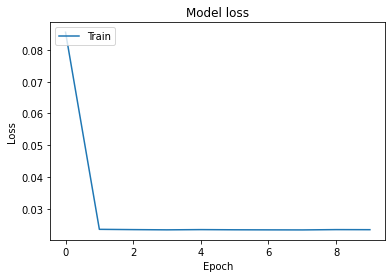

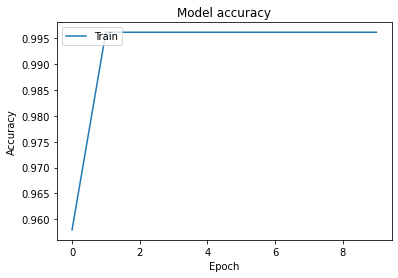

In [28]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
#plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss.png', format='png', dpi=1200)
plt.show()


# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
#plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('accuracy.png', format='png', dpi=1200)
plt.show()

In [ ]:
y_pred = model1.predict(X_test)
y_pred = np.around(y_pred)

bilstm_acc = accuracy_score(y_pred, y_test)
bilstm_prec = precision_score(y_pred, y_test,average='weighted')
bilstm_rec = recall_score(y_pred, y_test,average='weighted')
bilstm_f1 = f1_score(y_pred, y_test,average='weighted')

In [45]:
storeResults1('BiLSTM',bilstm_acc,bilstm_prec,bilstm_rec,bilstm_f1)

# CNN

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
# representation of model layers
from keras.utils.vis_utils import plot_model

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print (X_train.shape, y_train.shape)
print( X_test.shape, y_test.shape)

(838859, 10) (838859,)
(209715, 10) (209715,)


In [33]:
X_train=X_train.values
X_test=X_test.values

X_train = X_train.reshape(-1, X_train.shape[1],1)
X_test = X_test.reshape(-1, X_test.shape[1],1)

Y_train=to_categorical(y_train)
Y_test=to_categorical(y_test)

In [34]:
verbose, epoch, batch_size = 1, 100, 2
activationFunction='relu'

def CNN():
    
    cnnmodel = Sequential()
    cnnmodel.add(Conv1D(filters=128, kernel_size=2, activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
    cnnmodel.add(MaxPooling1D(pool_size=2))
    cnnmodel.add(Dropout(rate=0.2))
    cnnmodel.add(Flatten())
    cnnmodel.add(Dense(2, activation='softmax'))
    cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
    cnnmodel.summary()
    return cnnmodel

cnnmodel = CNN()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 9, 128)            384       
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 4, 128)            0         
_________________________________________________________________
dropout (Dropout)            (None, 4, 128)            0         
_________________________________________________________________
flatten (Flatten)            (None, 512)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 1026      
Total params: 1,410
Trainable params: 1,410
Non-trainable params: 0
_________________________________________________________________


In [35]:
modelhistory = cnnmodel.fit(X_train, Y_train, epochs=10, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/10
335544/335544 [==============================] - 1686s 5ms/step - loss: 127.7834 - accuracy: 0.9660 - val_loss: 0.1160 - val_accuracy: 0.9716
Epoch 2/10
335544/335544 [==============================] - 2491s 7ms/step - loss: 0.1183 - accuracy: 0.9713 - val_loss: 0.1162 - val_accuracy: 0.9717
Epoch 3/10
335544/335544 [==============================] - 2492s 7ms/step - loss: 0.1289 - accuracy: 0.9713 - val_loss: 0.1156 - val_accuracy: 0.9717
Epoch 4/10
335544/335544 [==============================] - 2516s 7ms/step - loss: 0.1711 - accuracy: 0.9713 - val_loss: 0.1155 - val_accuracy: 0.9717
Epoch 5/10
335544/335544 [==============================] - 2530s 8ms/step - loss: 0.1205 - accuracy: 0.9713 - val_loss: 0.1168 - val_accuracy: 0.9716
Epoch 6/10
335544/335544 [==============================] - 2530s 8ms/step - loss: 0.1368 - accuracy: 0.9713 - val_loss: 0.1154 - val_accuracy: 0.9717
Epoch 7/10
335544/335544 [==============================] - 2512s 7ms/step - loss: 0.2403 - 

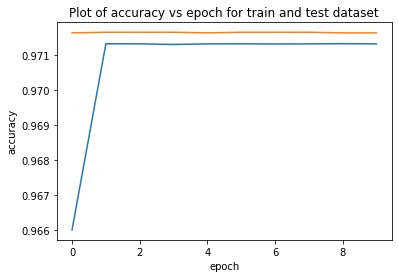

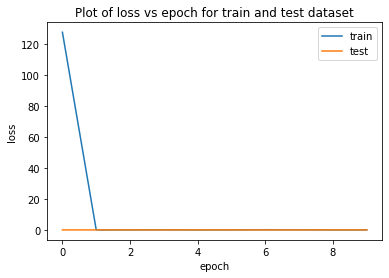

In [36]:
# Plot of accuracy vs epoch for train and test dataset
plt.plot(modelhistory.history['accuracy'])
plt.plot(modelhistory.history['val_accuracy'])
plt.title("Plot of accuracy vs epoch for train and test dataset")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

# Plot of loss vs epoch for train and test dataset
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title("Plot of loss vs epoch for train and test dataset")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [37]:
cnnpredictions = cnnmodel.predict(X_test, verbose=1)
cnn_predict=np.argmax(cnnpredictions,axis=1)

y_pred = cnnmodel.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred,axis=1)

#y_prob = cnnmodel.predict_proba(X_test)[:, 1]

cnn_acc = accuracy_score(y_pred, y_test)
cnn_prec = precision_score(y_pred, y_test,average='weighted')
cnn_rec = recall_score(y_pred, y_test,average='weighted')
cnn_f1 = f1_score(y_pred, y_test,average='weighted')



26215/26215 [==============================] - 40s 2ms/step


In [38]:
storeResults1('CNN',cnn_acc,cnn_prec,cnn_rec,cnn_f1)

# CNN + LSTM

In [39]:
import tensorflow as tf
tf.keras.backend.clear_session()

model_en = tf.keras.models.Sequential([tf.keras.layers.Conv1D(filters=64,kernel_size=5,strides=1,padding="causal",activation="relu",input_shape=(X_train.shape[1],X_train.shape[2])),
    tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding="valid"),
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, strides=1, padding="causal", activation="relu"),
    tf.keras.layers.MaxPooling1D(pool_size=2, strides=1, padding="valid"),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(2)
])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(5e-4,
                                                             decay_steps=1000000,
                                                             decay_rate=0.98,
                                                             staircase=False)

model_en.compile(loss=tf.keras.losses.MeanSquaredError(),
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.8),
              metrics=['acc'])
model_en.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 10, 64)            384       
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 9, 64)             0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 9, 32)             6176      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 8, 32)             0         
_________________________________________________________________
lstm (LSTM)                  (None, 8, 128)            82432     
_________________________________________________________________
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               1

In [40]:
modelhistory = model_en.fit(X_train, Y_train, epochs=10, verbose=verbose, validation_split=0.2, batch_size = batch_size)

Epoch 1/10
335544/335544 [==============================] - 8545s 25ms/step - loss: 0.0314 - acc: 0.9713 - val_loss: 0.0276 - val_acc: 0.9717
Epoch 2/10
335544/335544 [==============================] - 8101s 24ms/step - loss: 0.0288 - acc: 0.9724 - val_loss: 0.0285 - val_acc: 0.9717
Epoch 3/10
335544/335544 [==============================] - 6480s 19ms/step - loss: 0.0294 - acc: 0.9714 - val_loss: 0.0273 - val_acc: 0.9717
Epoch 4/10
335544/335544 [==============================] - 8674s 26ms/step - loss: 0.0294 - acc: 0.9714 - val_loss: 0.0269 - val_acc: 0.9717
Epoch 5/10
335544/335544 [==============================] - 8763s 26ms/step - loss: 0.0291 - acc: 0.9714 - val_loss: 0.0265 - val_acc: 0.9717
Epoch 6/10
335544/335544 [==============================] - 8804s 26ms/step - loss: 0.0295 - acc: 0.9713 - val_loss: 0.0270 - val_acc: 0.9717
Epoch 7/10
335544/335544 [==============================] - 8796s 26ms/step - loss: 0.0294 - acc: 0.9714 - val_loss: 0.0269 - val_acc: 0.9717
Epoch 

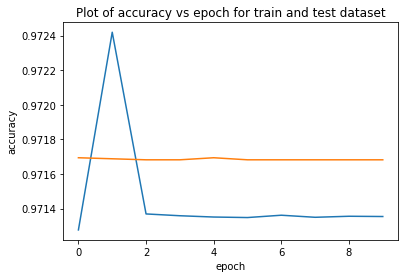

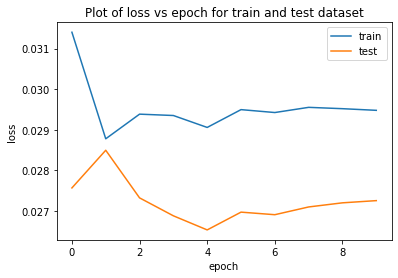

In [41]:
# Plot of accuracy vs epoch for train and test dataset
plt.plot(modelhistory.history['acc'])
plt.plot(modelhistory.history['val_acc'])
plt.title("Plot of accuracy vs epoch for train and test dataset")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

# Plot of loss vs epoch for train and test dataset
plt.plot(modelhistory.history['loss'])
plt.plot(modelhistory.history['val_loss'])
plt.title("Plot of loss vs epoch for train and test dataset")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [42]:
y_pred = model_en.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred,axis=1)

#y_prob = cnnmodel.predict_proba(X_test)[:, 1]

ense_acc = accuracy_score(y_pred, y_test)
ense_prec = precision_score(y_pred, y_test,average='weighted')
ense_rec = recall_score(y_pred, y_test,average='weighted')
ense_f1 = f1_score(y_pred, y_test,average='weighted')

#storeResults('CNNLSTM-NIDS',dl_acc,dl_prec,dl_rec,dl_f1)

6554/6554 [==============================] - 28s 4ms/step


In [56]:
storeResults1('CNNLSTM',ense_acc,ense_prec,ense_rec,ense_f1)

# Comparison

In [57]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model1,
                        'Accuracy' : accuracy1,
                        'Precision': precision1,
                        'Recall'   : recall1,
                        'F1-Score': f1score1
                      })

In [58]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.971,0.972,0.971,0.971
1,Deep Neural Network,0.993,0.993,0.993,0.993
2,BiLSTM,0.996,0.996,0.996,0.996
3,CNNLSTM,1.000,0.972,0.972,0.972


In [59]:
classifier = ML_Model1
y_pos = np.arange(len(classifier))

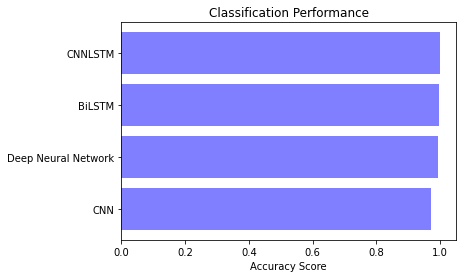

In [60]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy1, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

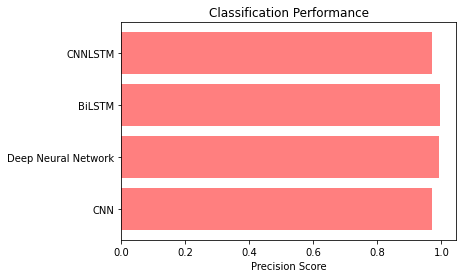

In [61]:
plt2.barh(y_pos, precision1, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

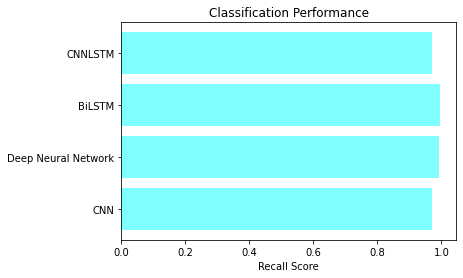

In [62]:
plt2.barh(y_pos, recall1, align='center', alpha=0.5,color='cyan')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

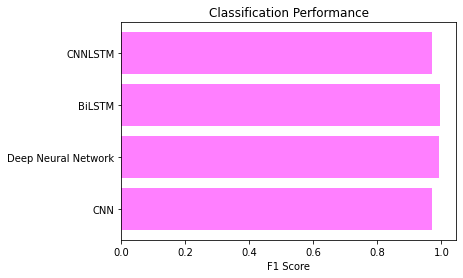

In [63]:
plt2.barh(y_pos, f1score1, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

In [64]:
model1.save('bilstm.h5')
model_en.save('model1.h5')